# HCNN for Fully Observable Chaotic Systems

## 1. Import Libraries

We begin by importing necessary libraries for data manipulation, visualization, and model development.

In [4]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
from chaotic_data import systems, utils # more details about this can be found in a separate folder at the root of the repo

## 2. Load the Lorenz System



We'll simulate the Lorenz system, a classic chaotic system, over a time span of 20 seconds with a time step of 0.01.

In [5]:
lorenz_data, _ = systems.LorenzSolver(start=0.0, stop=20.0, ics=(1.0, 0.0, 1.25), time_grid=0.01)
lorenz_data.shape  # Expected shape: (2000, 3)

torch.Size([2000, 3])

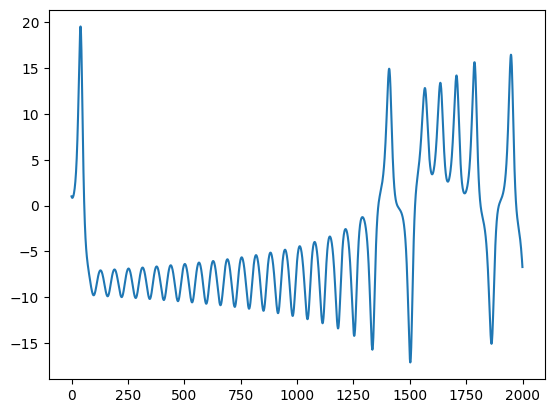

In [6]:
plt.plot(lorenz_data[:, 0])

The same logic applies to the Rabinovich-Fabrikan and the Rossler system

In [7]:
rabi_data, _= systems.RabinovichFabrikantSolver(start=0.0, stop=20.0, ics=(-0.75 , 0.75 ,0.5), time_grid=0.01)
rabi_data.shape

torch.Size([2000, 3])

## 3. Normalize the Data

It's common practice to scale the data to a manageable range to stabilize learning.

In [8]:
norma = utils.Normalization_Strategy()
scaled_lorenz, avg_lorenz = norma.Scale_ToNormalize(data=lorenz_data, scaling_factor=0.02)
print(scaled_lorenz.shape , avg_lorenz.shape)  # 

torch.Size([2000, 3]) torch.Size([3])


If needed, we can recover the original values using:

In [9]:
original_lorenz = norma.ScaleBackTo_originals(
    scaled_tens_data=scaled_lorenz,
    scaling_factor=0.02,
    tens_avgs=avg_lorenz
)

original_lorenz.shape

(2000, 3)

## 4. Train-Test Split

Let's divide the time series into training and testing windows.

In [10]:
train_size = 1500
train_lorenz = scaled_lorenz[:train_size]
test_lorenz = scaled_lorenz[train_size:]
print(train_lorenz.shape, test_lorenz.shape)

torch.Size([1500, 3]) torch.Size([500, 3])


## 5. Prepare Batched Input Data

We'll use sliding windows to segment the time series into overlapping sequences for training. We set the window_size to 200 time steps

In [11]:
data_sliding = utils.SlidingWindowDataset(data=train_lorenz, window_size=200)
sliced_data = data_sliding.sliding_windows_shift_to(train_lorenz, 200)

print(sliced_data.shape)  

torch.Size([1301, 200, 3])


You can also extract a long context window and its associated future observations. 

The context window can be located randomly within the train set (`random` in the image below)
or chosen to be carefully at the  end of the train set for forecast purpose (`last`).


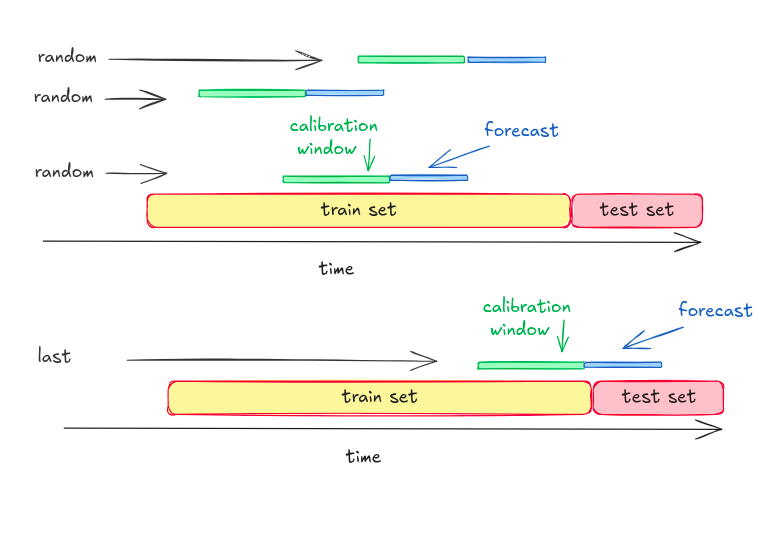

In [12]:
from IPython.display import Image


Image(filename='img_usage/sliding_windows_usage.png')

For a randomly selected context window of length 200, this method generates the subsequent 500 time steps. This approach can be utilized during inference to evaluate the model's ability to leverage a calibration window for forecasting. For instance, it is useful to test the model accuracy to predict the subsequent time steps. given the initial conditions.

In [13]:
calibration_window_length =200
forecast_window_length = 500

context_data_r, toforecast_data_r = data_sliding.contextwindow_testdata_generator(
    context_size=calibration_window_length, fcast_size=forecast_window_length, location='random_'
)

The same logic applies when the location is `last`.

In [14]:
context_data_l, toforecast_data_l = data_sliding.contextwindow_testdata_generator(
    context_size=1, fcast_size=1499, location='last_'
)

## 6. DataLoader for Training

We wrap our training windows in a DataLoader to enable batch processing.

In [15]:
batch_size = 20
my_data_loader = utils.SlidingWindowDataLoader(dataset=sliced_data, batch_size=batch_size, shuffle=False)

## 7. Load HCNN Models

We'll now bring in the HCNN model architectures.

In [16]:
from HCNN.models import Vanilla_Model, PTF_Model, LForm_Model, LSpa_Model
from torch import nn

## 9. Train a Vanilla HCNN Model

We initialize a Vanilla HCNN model with the following configuration:

* `n_obs_vars = 3`: Specifies three observed variables.

* `n_hid_vars = 5`: Defines five hidden variables.

* `s0_nature='random_'`: Sets the initial hidden state values to random (alternative: `zeros_` for an all-zeros vector).

* `train_s0=True`: Makes the initial state vector trainable, allowing the weights of `s0` to be learned during training.

* `batch_size=data_window.size(0)`: Matches the batch size to the training data's batch size for efficient parallel processing.

* `init_range=(-0.5, 0.5)`: Specifies the initialization range for the model's weight parameters.


In [40]:
vanilla_model = Vanilla_Model(
    n_obs_vars=3, n_hid_vars=5, 
    s0_nature='random_', train_s0=True,
    batch_size=batch_size, init_range=(-0.5, 0.5)
)


In [41]:
vanilla_model.name

'VanillaModel_obs3_hid5_randInit-0.5to0.5_trainableS0'

Lets check the vanilla model trainable parameters and their respective size.

In [42]:
vanilla_model.state_dict()  

OrderedDict([('s0',
              tensor([[ 0.4160,  0.4953, -0.3360,  0.2586, -0.2782, -0.0813, -0.4449, -0.1305]])),
             ('cell.A.weight',
              tensor([[-0.2089,  0.4478, -0.1132,  0.4455, -0.0434, -0.1470, -0.2408, -0.3223],
                      [-0.1588,  0.1087,  0.4984, -0.1104, -0.4275, -0.3563, -0.3556, -0.3699],
                      [ 0.3342, -0.4925, -0.3954,  0.2598,  0.2633,  0.2572, -0.4777, -0.2803],
                      [ 0.4714,  0.3135,  0.0402, -0.0666, -0.4031,  0.1522,  0.2345, -0.4552],
                      [-0.2125, -0.3660,  0.1492,  0.4859, -0.2758,  0.3009,  0.1528, -0.2077],
                      [-0.0206,  0.0377, -0.3399,  0.3298,  0.3549,  0.2792,  0.2481, -0.4984],
                      [-0.2202, -0.0650, -0.0986, -0.3829, -0.4135, -0.4481, -0.4569, -0.2645],
                      [-0.0952, -0.2985,  0.1048,  0.4707, -0.2050,  0.4616,  0.1250, -0.2739]]))])

In [43]:
for param in vanilla_model.parameters():
    print(param.shape)  

torch.Size([1, 8])
torch.Size([8, 8])


###  Training Loop

We iterate over batches from the DataLoader, updating the model at each step.
 We also perform forecasting after each training update, using the  random calibration window instantiated earlier on.

In [44]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(vanilla_model.parameters(), lr=1e-4)

In [ ]:
context_data_r.shape , toforecast_data_r.shape

In [ ]:
for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = vanilla_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {vanilla_model.s0.grad}")
        print(f"Gradient (A weights): {vanilla_model.cell.A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = vanilla_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )

##  Partial Teacher Forcing Model


We initialize a Vanilla HCNN model with the following configuration:

* `n_obs_vars = 3`: Specifies three observed variables.

* `n_hid_vars = 5`: Defines five hidden variables.

* `s0_nature='random_'`: Sets the initial hidden state values to random (alternative: `zeros_` for an all-zeros vector).

* `train_s0=True`: Makes the initial state vector trainable, allowing the weights of `s0` to be learned during training.

* `batch_size=data_window.size(0)`: Matches the batch size to the training data's batch size for efficient parallel processing.

* `init_range=(-0.5, 0.5)`: Specifies the initialization range for the model's weight parameters.

* `target_prob = 0.35`: specifies the target probability for the partial teacher forcing mechanism.

* `drop_output =False`: whether to drop the output after the partial teacher forcing is applied( when `False`, the dropout elements are included as part of the loss calculation.)


In [ ]:

ptf_model =  PTF_Model(n_obs_vars=3, n_hid_vars=5, s0_nature='random_', train_s0=True, batch_size=batch_size,
                       target_prob=0.35, drop_output=False)

In [3]:
ptf_model.name

'PTFModel_obs3_hid5_randInit-0.75to0.75_trainableS0'

In [ ]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(ptf_model.parameters(), lr=1e-4)

for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = ptf_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {ptf_model.s0.grad}")
        print(f"Gradient (A weights): {ptf_model.cell.A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = ptf_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )

## LForm model

In [31]:
lform_model =  LForm_Model(n_obs_vars=3, n_hid_vars=5,
                                s0_nature='random_', train_s0=False, 
                                batch_size=batch_size,init_range=(-.25, .25), init_diag=1.0,)

In [45]:
lform_model.name

'LFormModel_obs3_hid5_randInit-0.25to0.25'

In [32]:
lform_model.state_dict()

OrderedDict([('s0',
              tensor([[ 0.2250,  0.1080, -0.0591,  0.0336,  0.0448, -0.0777, -0.1479, -0.1946]])),
             ('cell.A.weight',
              tensor([[-0.0662, -0.1488, -0.1123,  0.2427, -0.2089, -0.0403, -0.1574, -0.0726],
                      [ 0.0866,  0.0091, -0.2212, -0.1396,  0.0697, -0.0597,  0.0217,  0.0627],
                      [ 0.0126,  0.0095, -0.2026, -0.0142, -0.0316,  0.1874,  0.1274,  0.0348],
                      [ 0.1929, -0.0219,  0.1719, -0.1391,  0.1476,  0.0137, -0.1857,  0.1302],
                      [ 0.1410,  0.0955,  0.2090,  0.0650, -0.2333,  0.0142, -0.2001,  0.0753],
                      [ 0.1619, -0.1547, -0.1198,  0.1125,  0.1017, -0.1067, -0.2166,  0.1468],
                      [-0.0487,  0.1639, -0.0050, -0.1804, -0.0351, -0.1268,  0.0984, -0.1995],
                      [-0.0306, -0.1019,  0.0522, -0.0387, -0.0297, -0.1836, -0.1352,  0.2232]])),
             ('cell.D.weight',
              tensor([[1., 0., 0., 0., 0., 0., 0

In [ ]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(lform_model.parameters(), lr=1e-2)

for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = lform_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {lform_model.s0.grad}")
        print(f"Gradient (A weights): {lform_model.cell.A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = lform_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(toforecast_data_r[:, 0].numpy(), label="True", alpha=0.7)
plt.plot(results_forecast.forecasts[0, :, 0].detach().numpy(), label="Forecast", linestyle="--")
plt.title("Forecast vs True (Lorenz x-coordinate)")
plt.legend()
plt.show()

## LSpa Model

### Random Block Sparsity

In [46]:
lspa_model  = LSpa_Model(n_obs_vars=3, n_hid_vars=10,
                                s0_nature='random_', train_s0=True, batch_size=batch_size,
                                sparsity_ratio=0.25,  init_range=(-.25, .25), mask_type='random_block')

In [47]:
lspa_model.name

'LSpaModel_obs3_hid10_randInit-0.25to0.25_trainableS0'

In [ ]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(lspa_model.parameters(), lr=1e-3)

for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = lspa_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {lspa_model.s0.grad}")
        print(f"Gradient (A weights): {lspa_model.cell.Sparse_A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = lspa_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )

### Observable-linked Sparsity

In [48]:
lspa_model  = LSpa_Model(n_obs_vars=3, n_hid_vars=10,
                                s0_nature='random_', train_s0=True, batch_size=batch_size,
                                sparsity_ratio=0.25,  init_range=(-.25, .25), mask_type='non_obs_block')

In [49]:
lspa_model.name

'LSpaModel_obs3_hid10_randInit-0.25to0.25_trainableS0'

In [ ]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(lspa_model.parameters(), lr=1e-3)

for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = lspa_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {lspa_model.s0.grad}")
        print(f"Gradient (A weights): {lspa_model.cell.Sparse_A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = lspa_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(toforecast_data_r[:, 0].numpy(), label="True", alpha=0.7)
plt.plot(results_forecast.forecasts[0, :, 0].detach().numpy(), label="Forecast", linestyle="--")
plt.title("Forecast vs True (Lorenz x-coordinate)")
plt.legend()
plt.show()